# Performance Evaluation

In this notebook, we evaluate the effectiveness of the volatility-based trading strategy using standard portfolio performance metrics.

Objectives:
1. Measure risk-adjusted returns
2. Analyze downside risk and drawdowns
3. Compare strategy performance against benchmark returns
4. Evaluate portfolio stability and consistency

These metrics help determine whether the strategy provides meaningful improvement over passive market exposure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sp500 = pd.read_csv(
    "../data/SP500_processed.csv",
    index_col="Date",
    parse_dates=True
)

In [3]:
sp500["rolling_vol"] = (
    sp500["log_return"]
    .rolling(30)
    .std()
)

threshold = sp500["rolling_vol"].median()

sp500["signal"] = np.where(
    sp500["rolling_vol"] < threshold,
    1,
    0
)

sp500["strategy_return"] = (
    sp500["signal"].shift(1)
    * sp500["log_return"]
)

In [4]:
strategy_annual_return = (
    sp500["strategy_return"].mean()
    * 252
)

market_annual_return = (
    sp500["log_return"].mean()
    * 252
)

print("Strategy Annual Return:", strategy_annual_return)
print("Market Annual Return:", market_annual_return)

Strategy Annual Return: 0.036295352573711866
Market Annual Return: 0.12406294766346045


In [5]:
strategy_volatility = (
    sp500["strategy_return"].std()
    * np.sqrt(252)
)

market_volatility = (
    sp500["log_return"].std()
    * np.sqrt(252)
)

print("Strategy Volatility:", strategy_volatility)
print("Market Volatility:", market_volatility)

Strategy Volatility: 0.07782022260846305
Market Volatility: 0.17306514971181772


In [6]:
strategy_sharpe = (
    strategy_annual_return
    / strategy_volatility
)

market_sharpe = (
    market_annual_return
    / market_volatility
)

print("Strategy Sharpe:", strategy_sharpe)
print("Market Sharpe:", market_sharpe)

Strategy Sharpe: 0.46640000962635
Market Sharpe: 0.7168569054488781


In [7]:
sp500["portfolio_value"] = (
    100
    * (1 + sp500["strategy_return"]).cumprod()
)

In [8]:
rolling_peak = (
    sp500["portfolio_value"]
    .cummax()
)

In [9]:
drawdown = (
    sp500["portfolio_value"]
    - rolling_peak
) / rolling_peak

In [10]:
max_drawdown = drawdown.min()

print("Maximum Drawdown:", max_drawdown)

Maximum Drawdown: -0.16951411127525562


In [11]:
summary = pd.DataFrame({
    "Metric": [
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown"
    ],
    
    "Strategy": [
        strategy_annual_return,
        strategy_volatility,
        strategy_sharpe,
        max_drawdown
    ]
})

summary

,Metric,Strategy
0,Annual Return,0.036295
1,Annual Volatility,0.077820
2,Sharpe Ratio,0.466400
3,Maximum Drawdown,-0.169514


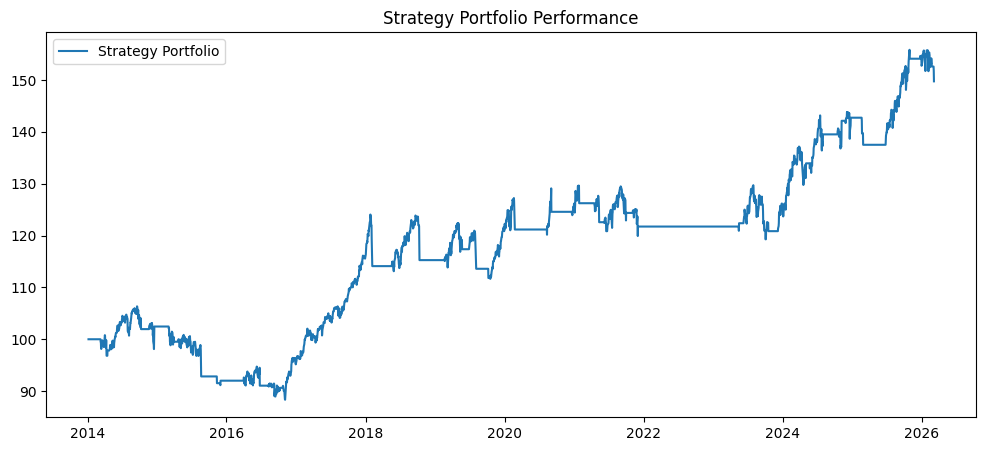

In [12]:
plt.figure(figsize=(12,5))

plt.plot(
    sp500["portfolio_value"],
    label="Strategy Portfolio"
)

plt.title("Strategy Portfolio Performance")

plt.legend()

plt.show()

## Performance Interpretation

The volatility-aware strategy attempts to improve risk-adjusted performance by dynamically reducing exposure during turbulent market conditions.

Performance metrics such as Sharpe ratio and maximum drawdown provide insight into whether the strategy delivers improved portfolio stability relative to passive market exposure.

# Overall Project Conclusion

This project developed a complete financial econometrics and quantitative trading workflow for volatility analysis and risk-aware portfolio management.

The study demonstrated:

1. Financial returns exhibit volatility clustering and ARCH effects
2. ARMA models capture limited mean predictability
3. GARCH models successfully model time-varying volatility
4. Volatility forecasts can inform dynamic portfolio allocation
5. Volatility-aware strategies may improve downside risk management

BTC consistently exhibited higher volatility, stronger tail risk, and more persistent high-volatility regimes relative to SP500.

The project integrates financial time series analysis, econometric modeling, volatility forecasting, risk estimation, and quantitative strategy evaluation into a unified research framework.